En primer lugar, hay que instalar ultralytics en google colab

In [ ]:
#pip install ultralytics

In [ ]:
from ultralytics import YOLO
import cv2
import zipfile
import os
import yaml
from collections import Counter
from google.colab.patches import cv2_imshow
from google.colab import files
import gdown


In [ ]:
# No es necesario montar el drive. El dataset, el archivo con los mejores parametros y el archivo con el mejor modelo, son descargados automaticamente desde drive a google colab a traves del enlace

# Usar solo si se tiene la carpeta en MiUnidad o MyDrive
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
import random
random.seed(1909)

## **Funciones**

Función que extrae un dataset en formato zip

In [ ]:
def lectura_dataset(ruta_origen, ruta_destino):

  with zipfile.ZipFile(ruta_origen, 'r') as zip:
      zip.extractall(ruta_destino)


´Función para contar el numero de imagenes en train , test o valid

In [ ]:
def contar_imagenes(ruta_imagenes):
  imagenes = [f for f in os.listdir(ruta_imagenes) if f.endswith(('.jpg', '.jpeg', '.png'))]

  return len(imagenes)

Función que devuelve una lista con el nombre de las clases según el data.yaml

In [ ]:
def lista_clases(ruta_yaml):

  with open(ruta_yaml, 'r') as f:
      data = yaml.safe_load(f)

  nombre_clases = data['names']
  return nombre_clases

Función que cuenta cuantos objetos hay etiquetados de cada clase en train, test o valid

In [ ]:
def Recuento_clase(ruta_labels):
  contador = Counter()

  # Leer todos los archivos .txt
  for archivo in os.listdir(ruta_labels):
      if archivo.endswith(".txt"):
          ruta_archivo = os.path.join(ruta_labels, archivo)
          with open(ruta_archivo, 'r') as f:
              for linea in f:
                  # Leer el id de las clases en cada txt
                  id_clase = int(linea.strip().split()[0])
                  contador[id_clase] += 1
  return contador

Función para borrar imágenes que no tengan anotaciones

In [ ]:
def borrar_fotos_nulas(ruta_labels, ruta_imagenes):

  # Contador
  borradas = 0

  # Recorre todas las imágenes
  for imagen in os.listdir(ruta_imagenes):
      if imagen.endswith((".jpg", ".jpeg", ".png")):

          # Obtiene el nombre de la imagen
          nombre_archivo = os.path.splitext(imagen)[0]
          archivo = nombre_archivo + ".txt"
          ruta_label = os.path.join(ruta_labels, archivo)

          # Si no existe el archivo txt, borra la imagen
          if not os.path.exists(ruta_label):
              os.remove(os.path.join(ruta_imagenes, imagen))
              borradas += 1

  print(f"Se eliminaron {borradas} imágenes sin etiquetas.")


##**Preprocesamiento de datos**

Leemos nuestro dataset zip en drive y lo descomprimimos en colab a una carpeta llamada TFM

In [ ]:
# Lectura del dataset

file_id = "10pSmhoIQFuP_2oq0cL60mmKhtxb3Mt_n"
url = f"https://drive.google.com/uc?id={file_id}"
nombre_dataset = "datasetTFM_drive.zip"
# Descargar el zip
gdown.download(url, nombre_dataset, quiet=False)

ruta_dataset =  "/content/datasetTFM_drive.zip" #"/content/drive/MyDrive/Pablo_Perez_Calvo_TFM/TFM.v18-tfm_militaryvehicle_dataset.yolov11.zip"
ruta_destino = "/content/TFM"

lectura_dataset(ruta_dataset, ruta_destino)

Downloading...
From (original): https://drive.google.com/uc?id=10pSmhoIQFuP_2oq0cL60mmKhtxb3Mt_n
From (redirected): https://drive.google.com/uc?id=10pSmhoIQFuP_2oq0cL60mmKhtxb3Mt_n&confirm=t&uuid=33821549-6c71-4217-9f52-8ab8b4ddc05e
To: /content/datasetTFM_drive.zip
100%|██████████| 950M/950M [00:22<00:00, 41.7MB/s]


In [ ]:
# Leemos y descargamos el documento de mejores parametros a google colab
file_id = "1DM23Ofrg_hYZ5TEg94Mj1BmRyzhMwLZM"
url = f"https://drive.google.com/uc?id={file_id}"
nombre_yaml = "best_hyperparameters.yaml"
gdown.download(url, nombre_yaml, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1DM23Ofrg_hYZ5TEg94Mj1BmRyzhMwLZM
To: /content/best_hyperparameters.yaml
100%|██████████| 570/570 [00:00<00:00, 1.24MB/s]


'best_hyperparameters.yaml'

In [ ]:
# Leemos y descargamos el mejor modelo entrenado en google colab
file_id = "1-3ELKQdZ2-iwRcPFLSaXg__zZPCKdKJb"
url = f"https://drive.google.com/uc?id={file_id}"
nombre_pt = "best.pt"
gdown.download(url, nombre_pt, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1-3ELKQdZ2-iwRcPFLSaXg__zZPCKdKJb
From (redirected): https://drive.google.com/uc?id=1-3ELKQdZ2-iwRcPFLSaXg__zZPCKdKJb&confirm=t&uuid=d6a6190b-493f-4a60-a4f9-317798053bc7
To: /content/best.pt
100%|██████████| 40.5M/40.5M [00:00<00:00, 75.0MB/s]


'best.pt'

In [ ]:
imagenes_train ="/content/TFM/train/images"
imagenes_valid = "/content/TFM/valid/images"
imagenes_test = "/content/TFM/test/images"

labels_train ="/content/TFM/train/labels"
labels_valid = "/content/TFM/valid/labels"
labels_test = "/content/TFM/test/labels"

print(f"Imagenes Train --> {contar_imagenes(imagenes_train)}")
print(f"Imagenes Valid --> {contar_imagenes(imagenes_valid)}")
print(f"Imagenes Test --> {contar_imagenes(imagenes_test)}")

print(f"Imagenes Totales --> {contar_imagenes(imagenes_train) + contar_imagenes(imagenes_test) + contar_imagenes(imagenes_valid)}")


Imagenes Train --> 6579
Imagenes Valid --> 1174
Imagenes Test --> 734
Imagenes Totales --> 8487


Comprobamos que no se hayan quedado imagenes sin anotaciones al eliminar algunas clases en la fase de creacion del dataset

In [ ]:
borrar_fotos_nulas(labels_train, imagenes_train)
borrar_fotos_nulas(labels_valid, imagenes_valid)
borrar_fotos_nulas(labels_test, imagenes_test)

Se eliminaron 0 imágenes sin etiquetas.
Se eliminaron 0 imágenes sin etiquetas.
Se eliminaron 0 imágenes sin etiquetas.


In [ ]:
ruta_yaml = "/content/TFM/data.yaml"

nombre_clases = lista_clases(ruta_yaml)
print("Nombre de las clases:", nombre_clases)

contador_clases = Recuento_clase(labels_train)
for id_clase, clase in contador_clases.items():
    nombre_clase = nombre_clases[id_clase]
    print(f"{nombre_clase}: {clase} objetos")

Nombre de las clases: ['military_aircraft', 'military_helicopter', 'military_truck', 'rocket_launcher', 'tank']
military_aircraft: 2422 objetos
tank: 2661 objetos
military_truck: 1986 objetos
military_helicopter: 1862 objetos
rocket_launcher: 1077 objetos


Comprobamos que no haya imagenes duplicadas

In [ ]:
# Obtener todas las imagenes
imagenes = []
for i in [imagenes_train, imagenes_valid, imagenes_test]:
    for f in os.listdir(i):
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            imagenes.append(f)

# Contar repetidas
contador = Counter(imagenes)
duplicados = [nombre for nombre, cuenta in contador.items() if cuenta > 1]

print(f"Número de imágenes duplicadas: {len(duplicados)}")
for dup in duplicados:
    print("Imagen duplicada:", dup)


Número de imágenes duplicadas: 0


## **Implementación YOLO**

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Wed Sep 10 19:23:46 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             46W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

Utilizaremos un modelo yolo11 para el entrenamiento

In [ ]:
# Cargar modelo preentrenado
model = YOLO('yolo11m.pt')

Se ha realizado un ajuste de hiperparámetros para optimizar los resultados del entrenamiento. La combinación ganadora de parámetros se utilizará durante el entrenamiento

In [ ]:
model.tune(
    data="/content/TFM/data.yaml",
    epochs=30,
    batch=16,
    #name="/content/drive/MyDrive/yolo_runs/tune",
    resume=True
)

Tuner: Initialized Tuner instance with 'tune_dir=/content/drive/MyDrive/yolo_runs/tune'
Tuner: 💡 Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Resuming tuning run /content/drive/MyDrive/yolo_runs/tune from iteration 8...
Tuner: Starting iteration 8/10 with hyperparameters: {'lr0': 0.00816, 'lrf': 0.01263, 'momentum': 0.95792, 'weight_decay': 0.00053, 'warmup_epochs': 3.0, 'warmup_momentum': 0.83016, 'box': 8.96017, 'cls': 0.50736, 'dfl': 1.32615, 'hsv_h': 0.01172, 'hsv_s': 0.88263, 'hsv_v': 0.39515, 'degrees': 0.0, 'translate': 0.07181, 'scale': 0.48923, 'shear': 0.0, 'perspective': 0.0, 'flipud': 0.0, 'fliplr': 0.46738, 'bgr': 0.0, 'mosaic': 0.95743, 'mixup': 0.0, 'cutmix': 0.0, 'copy_paste': 0.0}
Saved /content/drive/MyDrive/yolo_runs/tune/tune_scatter_plots.png
Saved /content/drive/MyDrive/yolo_runs/tune/tune_fitness.png

Tuner: 8/10 iterations complete ✅ (4618.51s)
Tuner: Results saved to /content/drive/MyDrive/yolo_runs/tune
Tuner: Best fit

Finalmente, se entrena el modelo con los parámetros ganadores del ajuste durante 200 épocas

In [ ]:
best_hyp = "/content/best_hyperparameters.yaml"  #"/content/drive/MyDrive/Pablo_Perez_Calvo_TFM/yolo_runs/tune/best_hyperparameters.yaml"

model.train(
    data="/content/TFM/data.yaml",
    epochs=200,
    batch=16,
    imgsz=640,
    patience=30,
    save_period=10,
    #project="/content/drive/MyDrive/yolo_runs",
    #name="train_1909",
    cfg=best_hyp,
    seed=1909
)

Ultralytics 8.3.198 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=/content/drive/MyDrive/yolo_runs/tune/best_hyperparameters.yaml, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/TFM/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train_1909, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f645803af30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

Cargamos los pesos del modelo con mejores resultados durante el entrenamiento

In [ ]:
model = YOLO('/content/best.pt')  #YOLO('/content/drive/MyDrive/Pablo_Perez_Calvo_TFM/yolo_runs/train_1909/weights/best.pt')

Evaluamos el modelo tanto en valid como en test

In [ ]:
# Evaluar el modelo sobre el conjunto de validación
metricas_val = model.val(data='/content/TFM/data.yaml',
                         #project="/content/drive/MyDrive/Pablo_Perez_Calvo_TFM/yolo_runs",
                         #name="val_results_1909",
                         conf=0.45,
                         save_json=True)

Ultralytics 8.3.202 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11m summary (fused): 125 layers, 20,033,887 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 900.8±850.0 MB/s, size: 112.0 KB)
val: Scanning /content/TFM/valid/labels... 1174 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1174/1174 1.8Kit/s 0.7s
val: New cache created: /content/TFM/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 74/74 0.0it/s 31:44
                   all       1174       1724       0.93      0.894      0.926      0.742
     military_aircraft        253        427      0.966      0.923      0.954      0.761
   military_helicopter        301        344       0.94      0.907       0.93      0.681
        military_truck        206        288      0.877      0.868        0.9      0.729
       rocket_launcher        158        229      0.912      0.856      0.901    

In [ ]:
# Evaluar el modelo sobre el conjunto de test
metricas_test = model.val(data='/content/TFM/data.yaml', split='test',
                          #project="/content/drive/MyDrive/Pablo_Perez_Calvo_TFM/yolo_runs",
                          conf=0.45,
                          #name="test_results_1909"
                          )


Ultralytics 8.3.201 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1727.0±1022.1 MB/s, size: 193.1 KB)
val: Scanning /content/TFM/test/labels... 734 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 734/734 2.2Kit/s 0.3s
val: /content/TFM/test/images/acf04184ed8876b5_jpg.rf.a2f099ed484b063f7c359247831ae5b6.jpg: 1 duplicate labels removed
val: New cache created: /content/TFM/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 3, len(boxes) = 1168. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 2.7it/s 16.8s
                   all        734       1168      0.915      0.852      0.901      0.711
     military_aircraft        183        329     

Codigo utilizado para realizar predicciones en imágenes


image 1/1 /content/TFM/test/images/1c5f4ef3887266eb67d8d526e45f9afb_jpg.rf.9ec9642d803df7377910207dfc18a53f.jpg: 448x640 1 military_aircraft, 50.3ms
Speed: 2.8ms preprocess, 50.3ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)


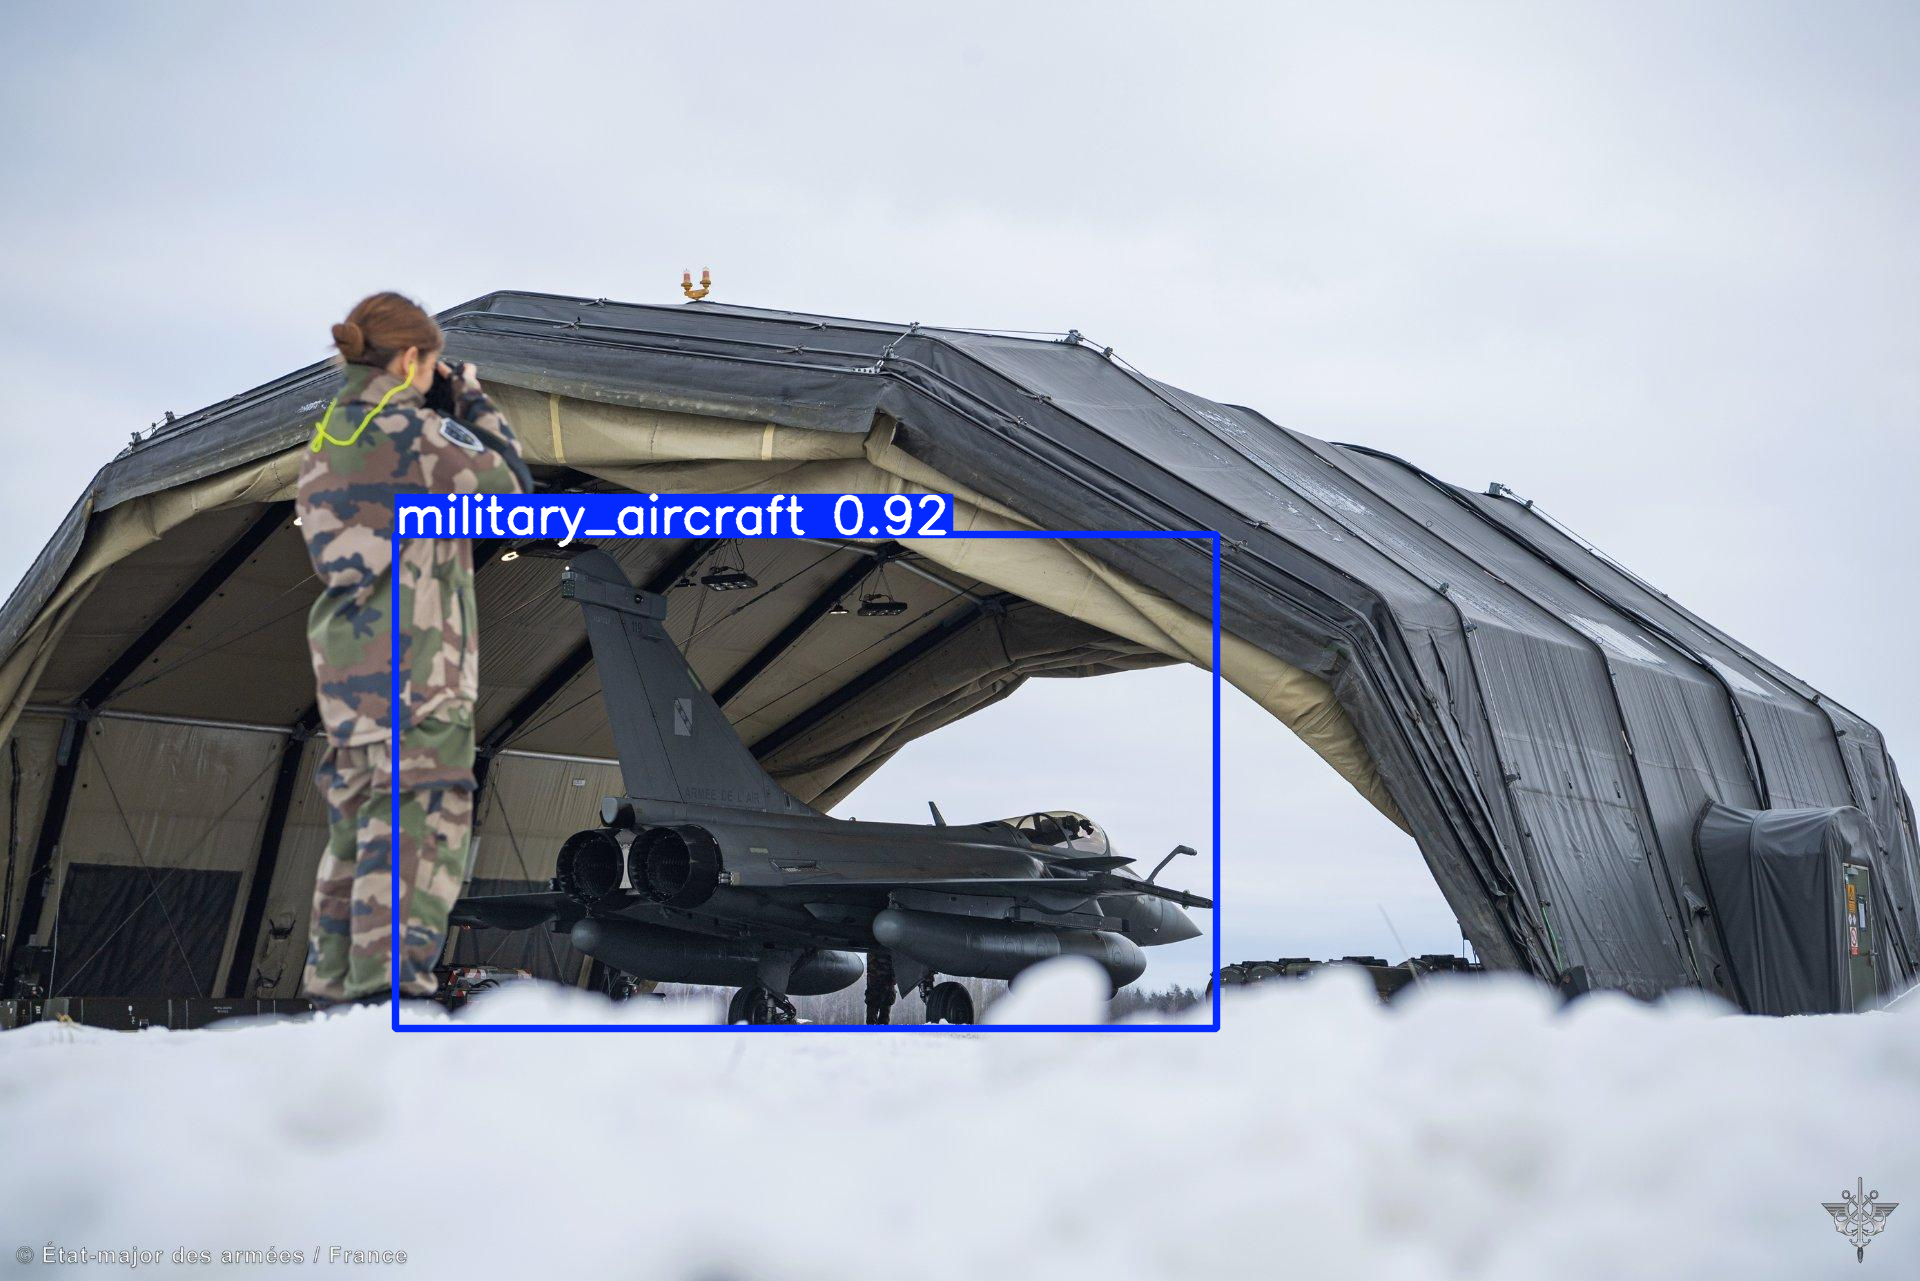

In [ ]:
# Predecir en imágenes subidas a colab
model.predict("/content/TFM/test/images/1c5f4ef3887266eb67d8d526e45f9afb_jpg.rf.9ec9642d803df7377910207dfc18a53f.jpg", conf=0.45)[0].show()

Codigo utilizado para realizar predicciones en video

In [ ]:
# HACE FALTA SUBIR UN VIDEO A COLAB PARA QUE PUEDA SER EJECUTADO

# Ruta del video subido a Colab
ruta_video = "/content/video9.mp4"

# Crear objeto para leer el video
video = cv2.VideoCapture(ruta_video)


fps = video.get(cv2.CAP_PROP_FPS)
ancho = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
alto = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))

# VideoWriter para guardar el video anotado
video_anotado = cv2.VideoWriter("/content/videoTFM17_anotado.mp4", cv2.VideoWriter_fourcc(*'mp4v'), fps, (ancho, alto))

while video.isOpened():
    leido, frame = video.read()
    if not leido:
        break

    # Realizar predicción  con YOLO
    resultados = model.predict(frame, conf=0.45, verbose=False)

    # Dibujar las predicciones en el frame
    frame_etiquetado = resultados[0].plot() if resultados[0].boxes is not None else frame

    # Guardar frame anotado en el video final
    video_anotado.write(frame_etiquetado)


video.release()
video_anotado.release()


files.download("/content/videoTFM17_anotado.mp4")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>